## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# importar librerías


In [2]:
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')
# cargar archivos  de los datasets 'traffic' y 'eco'

In [3]:
traffic.head()
# mostrar las primeras 5 filas de traffic para visualizar estructura

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
eco.head()
# mostrar las primeras 5 filas de eco para visualizar estructura

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
traffic.info()
traffic.head(3)
# Examinar la estructura de traffic

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son formato object (TEXTO) hay que covertirlas a formato de fecha para vincular el año 2024 con el df 'eco'.
- La columna 'country' sera depurada, p/ej. eliminar espacios innecesarios en formato de texto.
- Puntuacion y simbolos numericos estan en orden

In [6]:
eco.info()
eco.head(3)
# Examinar la estructura de eco

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, PM2.5(μg/m³) y Population(M), son formato object (TEXTO), ocupan cambio en formato 'int64', ademas de uniformar puntuacion y simbolos numericos.
-  La columna 'country' sera depurada en formato de texto.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
traffic = traffic.rename(columns={'Country' : 'country', 'City' : 'city', 'UpdateTimeUTC' : 'update_time_utc',
                                  'JamsDelay' : 'jams_delay', 'TrafficIndexLive' : 'traffic_index_live',
                                  'JamsLengthInKms' : 'jams_length_inkm',
                                  'JamsCount' : 'jams_count', 'TrafficIndexWeekAgo' : 'traffic_index_week_ago',
                                  'UpdateTimeUTCWeekAgo' : 'update_time_utc_week_ago',
                                  'TravelTimeLivePer10KmsMins' : 'travel_time_live_per10kms_mins',
                                  'TravelTimeHistoricPer10KmsMins' : 'travel_time_historic_per10kms_mins',
                                  'MinsDelay' : 'mins_delay'})
# Estandarizar los nombres de las columnas de traffic

traffic.columns
# verificar cambios

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_inkm', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per10kms_mins', 'travel_time_historic_per10kms_mins',
       'mins_delay'],
      dtype='object')

In [8]:
eco = eco.rename(columns={'Year' : 'year', 'City' : 'city', 'Country' : 'country',
                          'City GDP/capita' : 'city_gdp_capita', 'Unemployment %' : 'unemployment_pct',
                          'PM2.5 (μg/m³)' : 'pm2.5', 'Population (M)' : 'population_m'})
# Estandarizar los nombres de las columnas de eco

eco.columns
# verificar cambios

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [9]:
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce').dt.date
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce').dt.date 
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()

traffic.info()
traffic.head(3)
# verificar el cambio


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   country                             1004464 non-null  object 
 1   city                                1004464 non-null  object 
 2   update_time_utc                     1004464 non-null  object 
 3   jams_delay                          1004464 non-null  float64
 4   traffic_index_live                  1004464 non-null  float64
 5   jams_length_inkm                    1004464 non-null  float64
 6   jams_count                          1004464 non-null  float64
 7   traffic_index_week_ago              1004464 non-null  float64
 8   update_time_utc_week_ago            1004464 non-null  object 
 9   travel_time_live_per10kms_mins      1004464 non-null  float64
 10  travel_time_historic_per10kms_mins  1004464 non-null  float64
 11  mins_delay 

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_inkm,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,mins_delay
0,ARE,abu-dhabi,2025-01-13,650.7,36.0,109.1,162.0,30.0,2025-01-06,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13,540.4,30.0,101.4,136.0,27.0,2025-01-06,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13,71.8,7.0,18.9,23.0,6.0,2025-01-06,8.196278,8.196510,-0.000232


In [10]:
eco['city_gdp_capita'] = (eco['city_gdp_capita'].astype(str)
    .str.replace(',', '')
    .str.replace(r'\.(?=.*\')','', regex=True)
    .astype(float))
eco['unemployment_pct'] = (eco['unemployment_pct'].astype(str)
    .str.replace('%', '')
    .astype(float))
eco['population_m'] = (eco['population_m'].astype(str)
    .str.replace(',', '.')
    .astype(float))
eco['pm2.5'] = (eco['pm2.5'].astype(str)
    .str.replace(',', '.')
    .astype(float))
# Limpia separadores y convierte columnas numéricas en eco

eco['population'] = eco['population_m'] * 1000000
# Calcula la población total en unidades absolutas (Multiplica * 1000000)

eco.info()
eco.head(3)
# verificar el cambio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5             30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,population_m,population
0,2023,buenos-aires,Argentina,15.782,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14.475,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13.142,9.8,19.1,13.6,13600000.0


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year
# Extraer el año de las fechas en update_time_utc

traffic.info()
traffic.head(3)
# Verificar cambio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   country                             1004464 non-null  object 
 1   city                                1004464 non-null  object 
 2   update_time_utc                     1004464 non-null  object 
 3   jams_delay                          1004464 non-null  float64
 4   traffic_index_live                  1004464 non-null  float64
 5   jams_length_inkm                    1004464 non-null  float64
 6   jams_count                          1004464 non-null  float64
 7   traffic_index_week_ago              1004464 non-null  float64
 8   update_time_utc_week_ago            1004464 non-null  object 
 9   travel_time_live_per10kms_mins      1004464 non-null  float64
 10  travel_time_historic_per10kms_mins  1004464 non-null  float64
 11  mins_delay 

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_inkm,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13,650.7,36.0,109.1,162.0,30.0,2025-01-06,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13,540.4,30.0,101.4,136.0,27.0,2025-01-06,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13,71.8,7.0,18.9,23.0,6.0,2025-01-06,8.196278,8.196510,-0.000232,2025


In [12]:
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()
# Filtra las filas con registros del año 2024 y copiamos a nuevos datsets

display(traffic_2024.head())
display(eco_2024.head())
# Revisar dataframes nuevos

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_inkm,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31,12.9,5.0,2.5,5.0,2.0,2024-12-24,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31,136.0,21.0,20.6,32.0,3.0,2024-12-24,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31,455.2,31.0,40.4,72.0,4.0,2024-12-24,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31,399.4,27.0,38.0,75.0,6.0,2024-12-24,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31,366.4,28.0,39.8,82.0,9.0,2024-12-24,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,population_m,population
15,2024,buenos-aires,Argentina,18.117,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14.703,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13.349,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16.251,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8.899,12.4,15.2,3.9,3900000.0


In [13]:
print(traffic_2024.columns.tolist())
print(eco_2024.columns.tolist())
# verificar columnas de los datsets

['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_inkm', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per10kms_mins', 'travel_time_historic_per10kms_mins', 'mins_delay', 'year']
['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct', 'pm2.5', 'population_m', 'population']



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


In [14]:
traffic_city_year_2024 = (traffic_2024.groupby(['city', 'country', 'year'])
    [['jams_delay', 'traffic_index_live', 'jams_length_inkm',
      'jams_count', 'mins_delay', 'travel_time_live_per10kms_mins',
      'travel_time_historic_per10kms_mins']]
    .mean().reset_index())
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024.info()
traffic_city_year_2024.head()
# Mostrar y verificar resultado

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   city                                387 non-null    object 
 1   country                             387 non-null    object 
 2   year                                387 non-null    int64  
 3   jams_delay                          387 non-null    float64
 4   traffic_index_live                  387 non-null    float64
 5   jams_length_inkm                    387 non-null    float64
 6   jams_count                          387 non-null    float64
 7   mins_delay                          387 non-null    float64
 8   travel_time_live_per10kms_mins      387 non-null    float64
 9   travel_time_historic_per10kms_mins  387 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 30.4+ KB


,city,country,year,jams_delay,traffic_index_live,jams_length_inkm,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [15]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)
# tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_inkm,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es ... CIUDAD DE MEXICO


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [16]:
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']
# Seleccionar columnas clave de tráfico y economía

traffic_2024_small = traffic_city_year_2024[['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
                                             'jams_length_inkm', 'jams_count', 'mins_delay', 'travel_time_live_per10kms_mins',
                                             'travel_time_historic_per10kms_mins']].copy()
# Usar .copy() para crear los dos nuevos datasets reducidos

eco_2024_small = eco_2024[['city', 'year', 'city_gdp_capita', 'unemployment_pct', 'pm2.5', 'population']].copy()
# Usar .copy() para crear los dos nuevos datasets reducidos

merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')
# Unir datasets

merged.head()
# Mostrar las primeras 5 filas


,city,country,year,jams_delay,traffic_index_live,jams_length_inkm,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,city_gdp_capita,unemployment_pct,pm2.5,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11.124,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11.442,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16.251,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18.117,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12.381,8.2,13.5,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

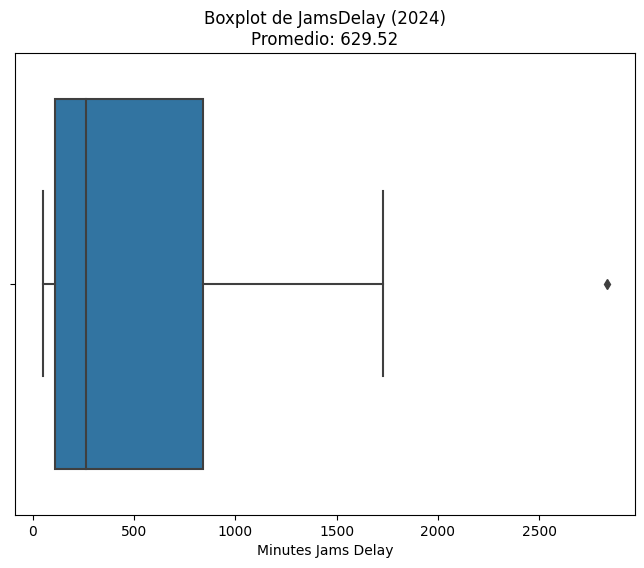

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x=merged['jams_delay'])
#plt.title("Distribucion Jams Delay 2024")
plt.xlabel('Minutes Jams Delay')

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

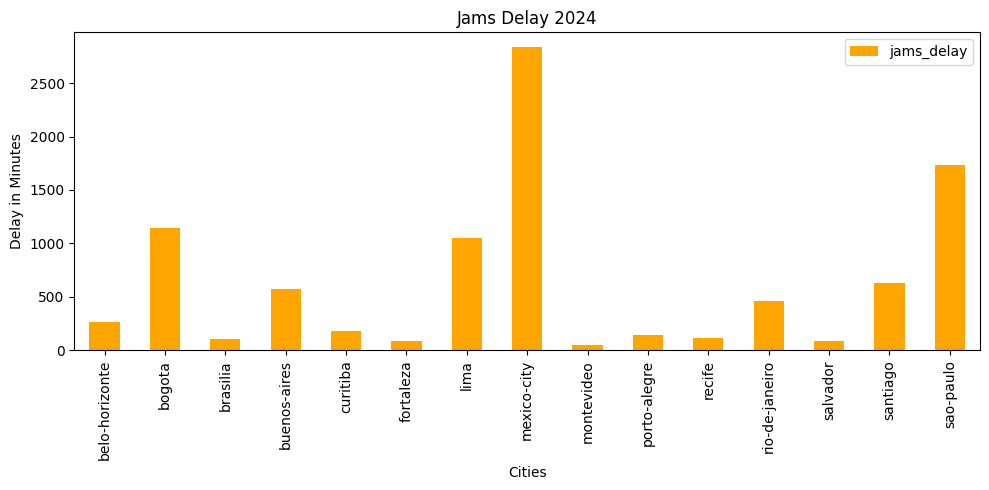

In [18]:
merged.plot(kind='bar', x='city', y='jams_delay', figsize=(10,5), color='orange')
plt.title('Jams Delay 2024')
plt.xlabel('Cities')
plt.ylabel('Delay in Minutes')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show
# Grafico retrasos en trafico en minutos

<function matplotlib.pyplot.show(close=None, block=None)>

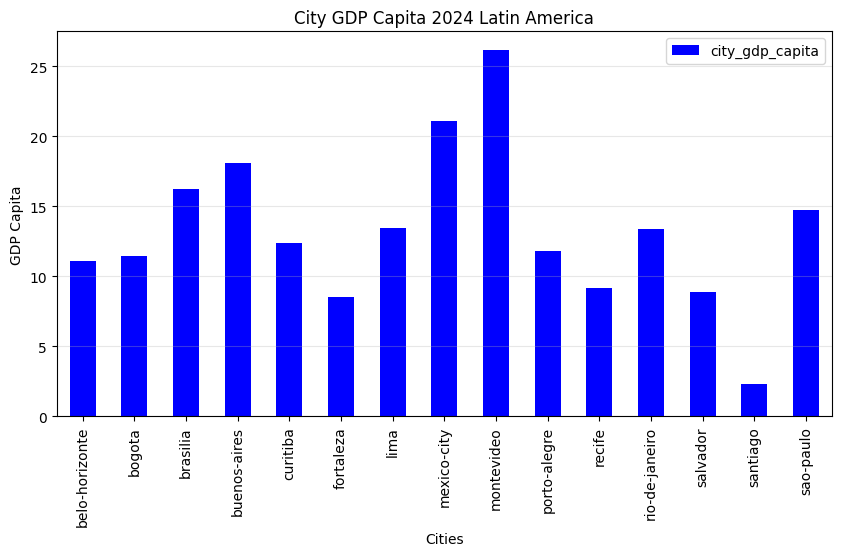

In [19]:
merged.plot(kind='bar', x='city', y='city_gdp_capita', figsize=(10,5), color='blue')
plt.title('City GDP Capita 2024 Latin America')
plt.xlabel('Cities')
plt.ylabel('GDP Capita')
plt.grid(axis='y', alpha=0.3)
plt.show

# Crear histograma para ver la distribución de la economía (city_gdp_capita)

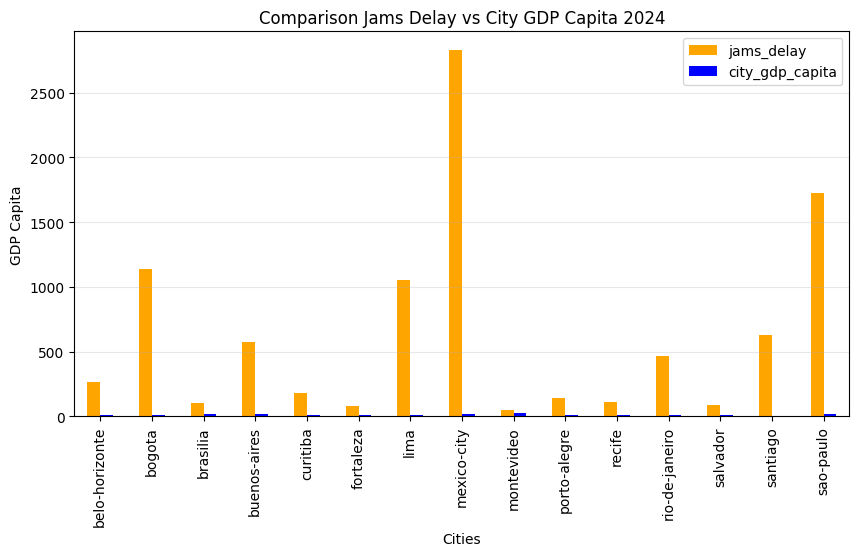

In [20]:
merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_capita'], color=['orange', 'blue'], figsize=(10,5))
plt.title('Comparison Jams Delay vs City GDP Capita 2024')
plt.xlabel('Cities')
plt.ylabel('GDP Capita')
plt.grid(axis='y', alpha=0.3)
plt.show
# Grafico comparacion Retrasos en Trafico vs GDP por Ciudad Latino America 2024
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])

plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: 
Es proporcional el PIB a la congestion en el trafico de las ciudades, cosiderando que son las capitales de las principales economias de Latino America : Brasilia, Buenos Aires, Ciudad de Mexico, Montevideo, Sao Paulo. Esto resulta en las siguientes consideraciones a señalar :
1. Montevideo, capital de Uruguay, ciudad relativamente pequeña (1.3 millones aproximadamente), presenta opuesta relacion PIB / Trafico al resto, con pocos retrasos en trafico y el PIB mas alto en la region. Una economia que funciona en eficiencia.
2. Por numero de ciudades (9), Brasil acumula el mayor PIB en conjunto, considerando que es el pais con mas habitanes de la region.
3. La Ciudad de Mexico, una de las grandes capitales del mundo por numero de habitantes y los tiempos de retraso en el trafico mas altosen el mundo, demuestra ineficiencia alta si consideramos urbanizacion nula. La ciudad funciona en el caos y por el volumen de habitantes.
4. especial mencion a capital Buenos Aires, 3ra ciudad con mayor GDP_per_Capita en Latino America e indice medio en retrasos en el trafico.
5. Gobiernos y Ciudades CENTRALIZADORAS en la region de America Latina.
6. ¿Por que no hay redistrbucion en las distintas formas genradoras de economia (industria, comercio, tecnologia, etc.)?


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [44]:
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)
# Exporta el dataset final como CSV

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?


In [ ]:
RESUMEN EJECUTIVO : 

###Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje)
y la productividad económica (PIB per cápita)?

    Cierto es que alto PIB per capita esta relacionado con la EFICIENTE movilidad de los habitantes en la ciudades alrededor
del mundo. A lo largo de la historia las grandes ciudades han sido, son y seran atractivas para los migrantes que procuran
mejorar su desarrollo economico para formar parte integral en el propio y consecuente avance del estado al que pertenecen. 
Conectar a la fuerza laboral con los puestos de trabajo, conectar a los bienes, productos y servicios con los consumidores, 
es el reto de los gobiernos, de las empresas y de la CORRECTA planeacion y urbanizacion en las grandes ciudades. A mayor densidad 
en la población, mayores la dificultades para lograr economias productivas.
En America Latina no funciona asi, cantidades significativas de atrasos en el trafico, tiempos muertos y/o perdidas monetarias
que afectan (en el cumulo de miles) al PIB de la ciudad, del estado y del Pais. 
¿Mejoras y/o mayor inversion en la infraestructura de las vialidades?
¿Reubicaciones masivas de fuerza laboral?
¿Son cosideradas opiciones en el mediano y largo plazo?


###Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
Cobertura de datos:

	A partir de los datasets en "Datos sobre congestión vehicular y condiciones de tráfico en ciudades del mundo." 
e "Indicadores económicos y ambientales por ciudad, recopilados por la OECD (Organización para la Cooperación y
el Desarrollo Económico)"; "traffic" y "eco" respectivamente.
Las variables clave para este analisis son las columnas con nombre :

Dataset traffic :
'city' : permite conectar informacion con dataset "eco"
'year' : permite analisis para el mismo period de tiempo con dataset "eco"
'jams_delay' : varaiable fundamental para relacionar con city_gdp_capita del data set "eco"

Dataset eco :
'city' : permite conectar informacion con dataset "traffic"
'year' : permite analisis para el mismo period de tiempo con dataset "traffic"
'city_gdp_capita' : varaiable fundamental pra relacionar con jams_delay en data set "traffic"

¿A mayor tiempo en trafico, menor GDP per Capita?


###Especifica los años analizados, número de ciudades y países incluidos.
Metodología (alto nivel):

Año de analisis : 2024
Numero de Ciudades : 15 latino americanas por 7 paises de la region 


###Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

Hallazgos iniciales:

Limpieza de datos : 

    En la estructura del Data Frame  traffic para las columnas de fecha realizamos cambio a formato datetime para poder vincularla
para el año 2024 con el df 'eco'.
Para columnas de texto ('country') depuramos espacios y uniformamos el texto.
Columnas en formato float estandarizamos puntuacion y simbolos numericos (, . %).

    En la estructura del Data Frame eco para las columnas City GDP/capita, Unemployment %, PM2.5(μg/m³) y Population(M), son de tipo 
object (TEXTO), cambiamos a formato 'int64' para uniformar puntuacion y simbologia en numeros (, . %).
Para columnas de texto ('country') depuramos espacios y uniformamos el texto.

    Para ambos Data Frame estandarizamos los titulos de las columnas en "lower_case".

    A partir de la columna "year" y "city" creamos un data set nuevo para integrar y relacionar 2 columnas :
"jams_delay" y "city_gdp_capita" con el metodo INNER, los valores que existen en ambos Data Frame. Base del analisis.

    boxplot : muestra mayor densidad por encima del 50% de los registro analizados con 1 outlier muy por encima del resto :
Ciudad de Mexico. Cuando el promedio es de 653.00 (numero redondeado) en jams delay, el outlier esta muy por encima de los 2500. 

    Grafico jams delay : Ciudad de Mexico, Sao Paolo, Bogota y Lima, se situan por encima del promedio, al menos 1000 minutos
totales en retrasos por congestion; mientras la mayoria del resto de la ciudades (8 de 11 restantes; 7 son ciudades brasileñas)
estan por debajo del nivel 500 minutos totales. 

    Grafico city gdp capita : Fortaleza, Recife, Salvador y especialmente Santiago presentan numeros inferiores en GDP y/o 
productividad economica. Aunque el resto de las ciudades aporten mas a la productividad, la consideracion general es que la 
movilidad es ineficiente en la region; debido a mala planeacion en la urbanizacion de las ciudades, vialidades insuficientes, 
mal sistema de transporte publico, entre otras posibles causas, etc. etc.


###Resume los patrones más importantes entre índices de tráfico y PIB per cápita.

    Patron mas importante : Ineficiente movilidad en Latino America. ¿El aporte al PIB sucede mas por volumen de gente que por
eficiente movilidad en fuerza laboral, de productos y bienes de consumo?

    Caso especial, la Ciudad De Mexico, ¿como cambiar patrones de ineficiencia en una urbe de tal magnitud? 
Esta ciudad resulta en el principal outlier en tiempo de retraso en el trafico, el 1ro a nivel mundial.
Bien merece ser un caso de studio aparte.

    Obtener dictamenes realizados por ingenieros especializados en urbanizacion para poder determinar rumbos de accion en 
movilidad urbana, opciones de medio - bajo impacto economico en arcas de gobierno (p/ej. : re definicion en sentidos de 
vialidades principales y secundarias en las grandes capitales latino americanas; re ubicacion de terminales, rutas y hasta
paradas del sistema de transporte publico, promover uso y proporcionar flotillas de bicicletas (existen proyectos que pueden
expandirse) en zonas y/o regiones de alta densidad urbana; entre otras tantas opciones que pueden generarse en el corto y 
mediano plazo).

    Especialistas en la materia lograran analisis certeros con generacion de propuestas y presupeustos para inversion en 
urbanizar, para mejorar los sistemas de transporte publico e incluso mas espacios verdes donde la fuerza laboral pueda tener 
acceso a tiempos de descanso y recreo, (en lugar de ir a casa - volver al lugar de trabajo).

###Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
###Recomendaciones
###Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis
adicionales, o propuestas de inversión.

###¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre
altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria 
para inversión en infraestructura de transporte?

    Ovbiando a la Ciudad de Mexico, las ciudades de Sao Paolo y Bogota presentan una fuerte relacion entre altos tiempos de
retraso en el trafico y bajo nivel de PIB. ¿Existen planes en los gobiernos respectivos con la intencion de promover alta 
eficiencia en movilidad? Detectar impedimentos a estos planes existentes. Considerando el impacto economico el mayor, que
alternativas hay para generar propuestas que involucre a los gobiernos, la iniciativa privada y a la Sociedad en general.
3 elementos que para un objetivo en comun : trabajo efectivo y productive que permita a la ploblacion en general mejorar
y aportar mas al PIB local, estatal, para el pais y para la region (Latino America). Trascender la etiqueta de economia 
emergente a una de economia fuerte y consolidada.

